# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

## Цель и задачи

 - **Цель:** построить интерпретируемую линейную модель, которая прогнозирует вероятность оттока клиента сервиса доставки кофе в следующем месяце. Модель должна давать качество по метрике `PR AUC`, так как задача решается в условиях дисбаланса классов: уходящих клиентов существенно меньше, чем остающихся. Решение должно быть готово к внедрению: вся предобработка и модель должны быть собраны в единый пайплайн и сохранены как артефакт.

- **Задачи:**
	1.	Тип задачи: бинарная классификация.
	2.	Целевая переменная: churn (1 — клиент ушёл, 0 — остался).
	3.	Признаки: числовые и категориальные характеристики поведения клиента за последние 4 недели (частота заказов, траты, активность в приложении, подписка, предпочтения и т.д.).
	4.	Ограничения: модель должна быть линейной и интерпретируемой (например, LogisticRegression), чтобы можно было объяснять влияние признаков.
	5. Метрики: основная — PR AUC, дополнительно — ROC AUC, LogLoss, F1, Precision, Recall, Accuracy.

- **Обенности данных и требования к качеству решения:**
    - в данных есть пропуски, требуется корректная обработка без утечек;
    - есть выбросы и признаки с “длинными хвостами” -> требуется аккуратная обработка;
    - категориальные признаки требуют кодирования;
    - нужно зафиксировать `random_state` для воспроизводимости;
    - итоговый пайплайн предобработки + модель необходимо сохранить (`joblib/pickle`) и проверить загрузку.

---

## Данные

Для анализа и построения модели используется датасет:
`coffee_churn_dataset.csv`

**Описание датасета coffee_churn_dataset.csv**:

Данные собраны из внутренних систем компании (транзакции, логи приложения, опросы) и агрегированы за последние 4 недели. Каждая строка — один клиент, данные представлены в формате готовой витрины.

**Поля датасета:**
 - `user_id` - идентификатор пользователя.
 - `days_since_last_order` - дней с последнего заказа.
 - `order_frequency_month` - среднее число заказов в месяц.
 - `order_frequency_week` - среднее число заказов в неделю.
 - `avg_order_value` - средний чек, руб.
 - `median_order_value` - медианный чек, руб.
 - `total_spent_last_month` - сумма заказов за месяц.
 - `total_spent_last_week` - сумма заказов за неделю.
 - `discount_usage_rate` - доля заказов со скидкой.
 - `last_coffee_type` - сорт кофе в последнем заказе.
 - `preferred_roast` - предпочитаемая обжарка.
 - `milk_preference` - предпочитаемый тип молока.
 - `seasonal_menu_tried` - пробовал ли сезонное меню.
 - `coffee_bean_origin` - страна происхождения зерна.
 - `last_drink_size` - размер последнего напитка.
 - `subscription_status` - статус подписки.
 - `app_opens_per_week` - среднее число открытий приложения в неделю.
 - `notifications_enabled` - включены ли уведомления.
 - `review_rating_last_10` - средняя оценка последних 10 заказов.
 - `review_rating_last_1` - оценка последнего заказа.
 - `app_crashes_last_month` - число зависаний приложения за месяц.
 - `seasons` - текущее время года.
 - `days_since_last_promo` - дней с последнего использования промо.
 - `phone_type` - тип устройства.
 - `coffee_preference_change` - менялись ли предпочтения.
 - `geo_location` - регион/география пользователя.
 - `churn` - целевой признак (ушёл/не ушёл).

---

### Структура проекта
1. Загрузка данных и первичное знакомство с датасетом.
2. `EDA`: анализ целевой переменной, дисбаланса классов, распределений признаков, пропусков, выбросов, категорий и корреляций (в т.ч. `PhiK` для смешанных типов).
3. Предобработка:
    - Разделение данных: `train/test` в пропорции 80/20 (20% — отложенный тест), `stratify` по `churn`, фиксация `random_state`
    - обработка пропусков,
    - обработка выбросов и отрицательных значений,
    - кодирование категориальных признаков,
    - масштабирование числовых признаков (`StandardScaler`),
    - сборка всего в единый `Pipeline` + `ColumnTransformer` без утечек.
4. Обучение моделей:
    - baseline (`DummyClassifier`),
    - основная модель (`LogisticRegression`).
5. Получение предсказаний и оценка качества на кросс-валидации.
6. Расчёт метрик (`PR AUC` — основная, остальные — дополнительные).
7. Улучшение модели:
    - генерация новых признаков на основе `EDA` и логики,
    - подбор гиперпараметров,
    - сравнение вариантов по `PR AUC`.
8. Финальная оценка качества на отложенной тестовой выборке.
9. Сохранение артефактов (пайплайн + модель), проверка загрузки и воспроизводимости предсказаний.

## Этап 1. Подготовка среды и библиотек
1. Установим и настроим библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируем `random_state`.

3. Загрузим данные из CSV-файла. Используем сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
try:
    import phik
except ModuleNotFoundError:
    !pip -q install phik

In [2]:
# Загрузка библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss, average_precision_score, accuracy_score, precision_score, recall_score, f1_score

In [3]:
# Загружаем датасет

RANDOM_STATE = 42
DATA_PATH = "../data/coffee_churn_dataset.csv"
DATA_URL = "https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv"

try:
    df = pd.read_csv(DATA_PATH, sep=",", decimal=".")
    print("Загружено из локального пути:", DATA_PATH)
except FileNotFoundError:
    df = pd.read_csv(DATA_URL, sep=",", decimal=".")
    print("Загружено по прямой ссылке:", DATA_URL)

df.shape, display(df.head(10))

Загружено по прямой ссылке: https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,...,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,...,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,...,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,...,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


((10450, 27), None)

## Этап 2. Исследовательский анализ данных

1. Изучим данные опишим, что известно о пользователях и их поведении.

2. Изучим целевую переменную. Исследуем на возможные особенности её распределения. Проверим, наблюдается ли дисбаланс классов в целевой переменной.

3. Исследуем признаки.

   - Определим, все ли из них важны.

   - Определим, какие из них можно удалить (если такие есть).

4. Исследуем пропущенные значения.
   
   - Рассмотрим, как они влияют на данные.

   - Выберем стратегию заполнения пропусков.

5. Проанализируем категориальные признаки.

   - Выясним, есть ли в данных признаки, которые можно кодировать.

   - Проанализируем признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Выберем возможные стратегии.

   - Определим, есть ли в данных признаки, которые можно удалить.

6. Проанализируем выбросы.

   - Определим, как они влияют на данные.

   - Выберем способ, которым их можно обработать.

7. Посчитаем корреляции между признаками. Построим необходимые визуализации. Определим, есть ли признаки, которые можно убрать, на основании их корреляции с другими.


In [4]:
# Быстрый осмотр данных

df.info()
df.isna().mean().sort_values(ascending=False).head(10)
df['churn'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

0    0.939809
1    0.060191
Name: churn, dtype: float64

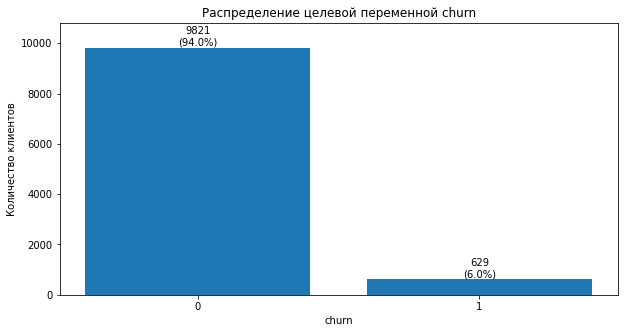

In [5]:
counts = df['churn'].value_counts().sort_index()
shares = df["churn"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(10, 5))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Распределение целевой переменной churn")
plt.xlabel("churn")
plt.ylabel("Количество клиентов")
plt.ylim(0, counts.max() * 1.10)

for i, (n, p) in enumerate(zip(counts.values, shares.values)):
    plt.text(i, n, f"{n}\n({p*100:.1f}%)", ha="center", va="bottom")

plt.show()

Датасет имеет 10450 строк, 27 колонок
 - пропуски есть почти везде (и в числовых, и в категориальных)
 - Целевая переменная `churn` несбалансирована: доля класса 1 (отток) составляет около 6%, класс 0 — около 94%. Поэтому в качестве основной метрики выбираем `PR AUC`, так как она более информативна при дисбалансе классов.
 - при выводе первых 10ти строк видно подозрительное значение: `total_spent_last_week` = -41.895... — траты не должны быть отрицательными -> это надо отдельно проверить

### **Преверяем данные да дубли:**

In [6]:
# Проверка на полные дубликаты
df.duplicated().sum()

0

полных дубликатов в данных нет

In [7]:
# Проверка на скрытые дубликаты:
user_dups = df['user_id'].duplicated().sum()
user_dups

0

In [8]:
# Проверка квази-дубликатов
feature_cols = [c for c in df.columns if c != 'user_id']
dup_wo_user = df.duplicated(subset=feature_cols, keep=False).sum()
dup_wo_user

814

In [9]:
# Считаем группы
dup_rows = df.duplicated(subset=feature_cols, keep=False).sum()
dup_extra = df.duplicated(subset=feature_cols, keep="first").sum()
dup_groups = df.loc[df.duplicated(subset=feature_cols, keep=False), feature_cols].drop_duplicates().shape[0]

dup_rows, dup_extra, dup_groups

(814, 414, 400)

In [10]:
feature_cols_no_target = [c for c in df.columns if c not in ["user_id", "churn"]]
df.duplicated(subset=feature_cols_no_target).sum()

414

In [11]:
# Считаем группы
dup_rows_x = df.duplicated(subset=feature_cols_no_target, keep=False).sum()
dup_extra_x = df.duplicated(subset=feature_cols_no_target, keep="first").sum()
dup_groups_x = df.loc[df.duplicated(subset=feature_cols_no_target, keep=False), feature_cols_no_target].drop_duplicates().shape[0]

dup_rows_x, dup_extra_x, dup_groups_x

(814, 414, 400)

In [12]:
# Проверяем есть ли одинаковые X с разным target

tmp = df.groupby(feature_cols_no_target)["churn"].nunique()
conflicting_profiles = (tmp > 1).sum()
total_dup_profiles = tmp.shape[0]

conflicting_profiles, total_dup_profiles

(0, 2190)

In [13]:
# Удаляем квази дубли:
before = df.shape[0]
df = df.drop_duplicates(subset=feature_cols_no_target, keep="first")
after = df.shape[0]

print(f"Удалено квази-дубликатов по X: {before - after}")
print("Новый размер:", df.shape)

Удалено квази-дубликатов по X: 414
Новый размер: (10036, 27)


Полных дубликатов строк не обнаружено, `user_id` уникален. При этом выявлены квази-дубликаты по набору признаков (без `user_id`): 814 строк входят в группы повторяющихся профилей, при этом “лишних” повторов 414, а количество уникальных повторяющихся профилей — 400. Это означает, что у части клиентов совпадает набор поведенческих и транзакционных характеристик. Такие квази-дубликаты не удаляем, так как это реальные наблюдения и удаление может исказить распределения.

Дополнительно проверили наличие одинаковых наборов признаков (X) с разными значениями целевой переменной. Конфликтов не обнаружено (0): для каждой уникальной комбинации признаков значение `churn` однозначно. Всего в данных 2190 уникальных профилей X.

### Изучаем признаки и их распределение

In [14]:
# Разделим признаки на числовые и категориальные
target = 'churn'
id_col = 'user_id'

num_cols = df.select_dtypes(include=['number']).columns.drop(target)
cat_cols = df.select_dtypes(include=['object']).columns.drop(id_col)

num_cols, cat_cols

(Index(['days_since_last_order', 'order_frequency_month',
        'order_frequency_week', 'avg_order_value', 'median_order_value',
        'total_spent_last_month', 'total_spent_last_week',
        'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week',
        'notifications_enabled', 'review_rating_last_10',
        'review_rating_last_1', 'app_crashes_last_month',
        'days_since_last_promo', 'coffee_preference_change'],
       dtype='object'),
 Index(['last_coffee_type', 'preferred_roast', 'milk_preference',
        'coffee_bean_origin', 'last_drink_size', 'subscription_status',
        'seasons', 'phone_type', 'geo_location'],
       dtype='object'))

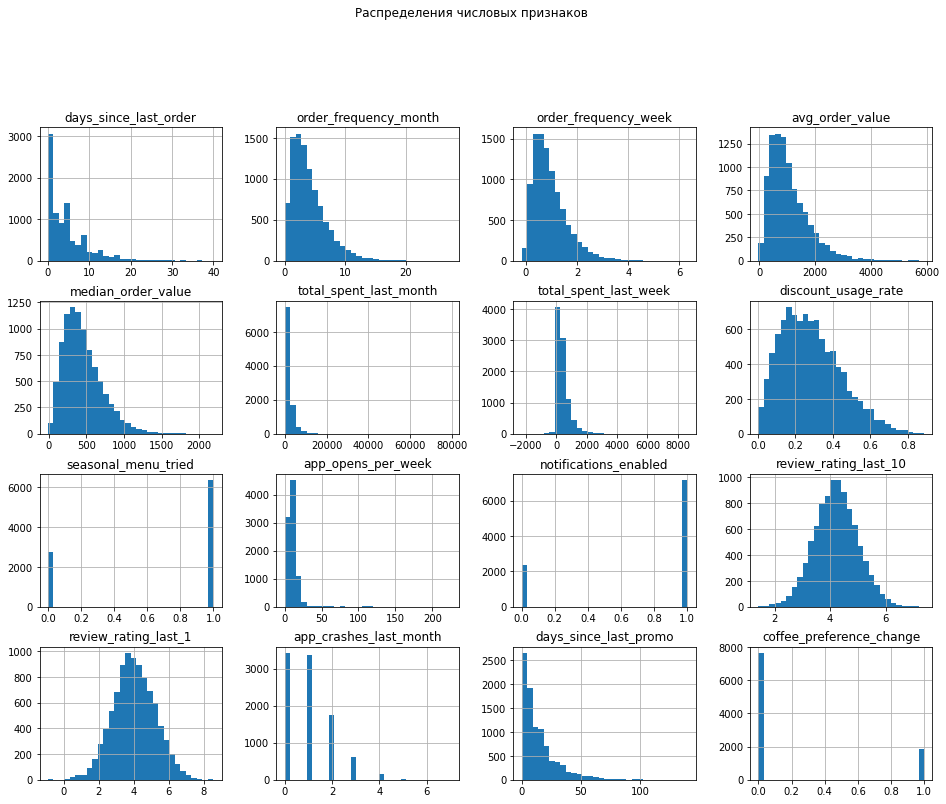

In [15]:
# Распределение числовых признаков (гистограммы)
df[num_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Распределения числовых признаков", y=1.02)
plt.show()

In [16]:
df['app_crashes_last_month'].nunique()

8

In [17]:
df[num_cols].describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change
count,9134.000000,9454.000000,9659.000000,9476.000000,9232.000000,9748.000000,9120.000000,9653.000000,9086.000000,9179.000000,9522.000000,9362.000000,9214.000000,9342.000000,9338.000000,9454.000000
mean,4.391285,4.025081,0.929998,1063.254822,452.643042,1945.439275,412.764040,0.283965,0.699868,11.327660,0.753518,4.207272,4.022551,1.015521,14.562969,0.193146
std,4.853955,2.830559,0.657909,707.615045,258.899193,2375.596627,446.166446,0.158722,0.458340,14.512342,0.430985,0.782584,1.205782,1.010847,15.308919,0.394787
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000
25%,1.000000,1.931762,0.445322,552.806327,263.584473,628.239460,136.251186,0.159470,0.000000,6.335269,1.000000,3.675187,3.217563,0.000000,4.000000,0.000000
50%,3.000000,3.378246,0.783019,898.368853,405.841711,1294.345827,287.099474,0.263945,1.000000,9.214974,1.000000,4.205958,3.989637,1.000000,10.000000,0.000000
75%,6.000000,5.434299,1.258550,1405.845229,591.515371,2475.248185,549.310546,0.386869,1.000000,12.715057,1.000000,4.718466,4.844709,2.000000,20.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000


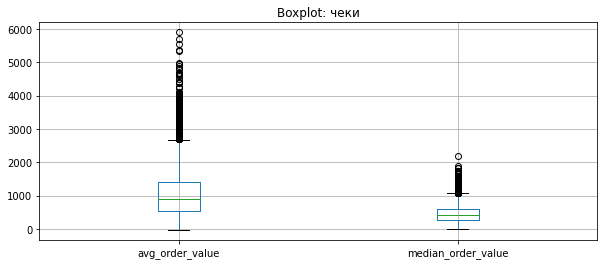

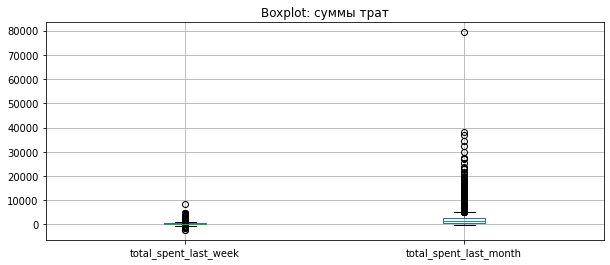

In [18]:
# Деньги и чеки
plt.figure(figsize=(10, 4))
df[["avg_order_value", "median_order_value"]].boxplot(rot=0)
plt.title("Boxplot: чеки")
plt.show()

plt.figure(figsize=(10, 4))
df[["total_spent_last_week", "total_spent_last_month"]].boxplot(rot=0)
plt.title("Boxplot: суммы трат")
plt.show()

В денежных признаках наблюдаются выраженные выбросы и сильная асимметрия распределений, особенно у `total_spent_last_month`. Для устойчивой работы линейной модели потребуется масштабирование и/или обработка выбросов (например, отсечение по верхнему квантилю или использование лог-преобразования для признаков с длинным хвостом). Также ранее обнаружены отрицательные значения, которые будут обработаны отдельно.

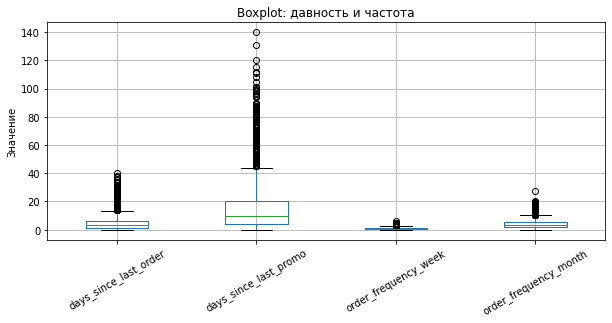

In [19]:
# Частота и давност
rf_cols = [
    "days_since_last_order",
    "days_since_last_promo",
    "order_frequency_week",
    "order_frequency_month",
]

plt.figure(figsize=(10, 4))
df[rf_cols].boxplot(rot=30)
plt.title("Boxplot: давность и частота")
plt.ylabel("Значение")
plt.show()

Признаки давности и частоты имеют скошенные распределения и выбросы. Наиболее выраженный хвост наблюдается у `days_since_last_promo` (есть пользователи, давно не использовавшие промо). Также присутствуют редкие клиенты с высокой частотой заказов. Для линейной модели потребуется масштабирование, а отрицательные значения частоты (обнаруженные ранее) будут обработаны как аномалии.

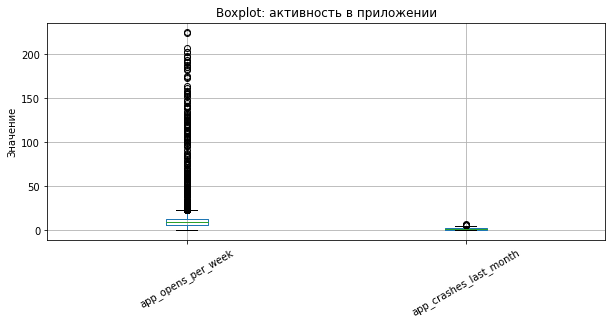

In [20]:
# Активность в приложении
app_cols = [
    "app_opens_per_week",
    "app_crashes_last_month",
]

plt.figure(figsize=(10, 4))
df[app_cols].boxplot(rot=30)
plt.title("Boxplot: активность в приложении")
plt.ylabel("Значение")
plt.show()

Признак `app_opens_per_week` имеет выраженный длинный хвост и большое количество выбросов (есть клиенты с очень высокой активностью в приложении). `app_crashes_last_month` — дискретный признак с небольшим числом экстремальных значений.

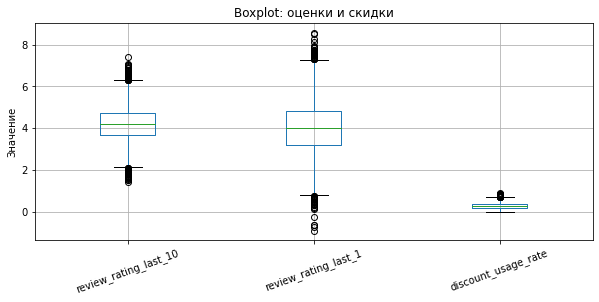

In [21]:
# Оценки + скидки
quality_cols = [
    "review_rating_last_10",
    "review_rating_last_1",
    "discount_usage_rate",
]

plt.figure(figsize=(10, 4))
df[quality_cols].boxplot(rot=20)
plt.title("Boxplot: оценки и скидки")
plt.ylabel("Значение")
plt.show()

Оценки по последним заказам в среднем сосредоточены около 4 баллов. При этом у `review_rating_last_1` обнаружены невалидные отрицательные значения (ниже 0), что указывает на ошибки в данных. Такие значения будут заменены на пропуски и обработаны на этапе предобработки. `discount_usage_rate` находится в ожидаемом диапазоне 0–1, распределение сосредоточено в районе 0.2–0.4, присутствуют редкие значения с высокой долей скидок.

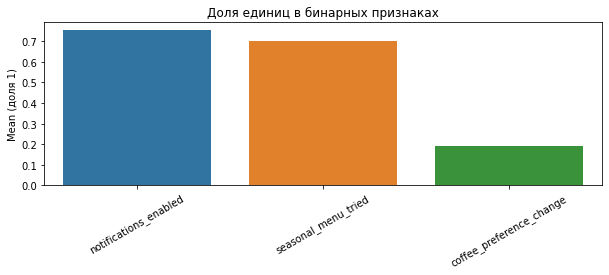

In [22]:
# Бинарные признаки
bin_cols = ["seasonal_menu_tried", "notifications_enabled", "coffee_preference_change"]

plt.figure(figsize=(10, 3))
bin_means = df[bin_cols].mean().sort_values(ascending=False)
sns.barplot(x=bin_means.index, y=bin_means.values)
plt.title("Доля единиц в бинарных признаках")
plt.ylabel("Mean (доля 1)")
plt.xticks(rotation=30)
plt.show()

Бинарные признаки имеют следующие доли единиц: `notifications_enabled` — около 75%, `seasonal_menu_tried` — около 70%, `coffee_preference_change` — около 19%. Это показывает, что уведомления и сезонное меню распространены среди большинства клиентов, тогда как изменение предпочтений встречается заметно реже.

In [23]:
# Проверяем количество отрицательных значений
bad_cols = [
    "order_frequency_week",
    "avg_order_value", "median_order_value",
    "total_spent_last_month", "total_spent_last_week",
    "review_rating_last_1"
]

(df[bad_cols] < 0).sum().sort_values(ascending=False)

total_spent_last_week     160
order_frequency_week       74
review_rating_last_1        5
avg_order_value             2
median_order_value          2
total_spent_last_month      2
dtype: int64

In [24]:
# Доли отрицательных значений
((df[bad_cols] < 0).mean() * 100).round(2).sort_values(ascending=False)

total_spent_last_week     1.59
order_frequency_week      0.74
review_rating_last_1      0.05
avg_order_value           0.02
median_order_value        0.02
total_spent_last_month    0.02
dtype: float64

В данных обнаружены отрицательные значения в ряде признаков. Наибольшая доля таких значений у `total_spent_last_week` (1.64%) и `order_frequency_week` (0.79%); в остальных признаках доля отрицательных значений не превышает 0.06%. Возможные причины — возвраты или ошибки агрегации. На этапе предобработки будет применено правило обработки невалидных значений (без использования целевой переменной) внутри пайплайна.

### Исследуем пропущенные значения

In [25]:
# Общее количество пропусков:
df.isna().sum()

user_id                       0
days_since_last_order       902
order_frequency_month       582
order_frequency_week        377
avg_order_value             560
median_order_value          804
total_spent_last_month      288
total_spent_last_week       916
discount_usage_rate         383
last_coffee_type            250
preferred_roast             111
milk_preference             641
seasonal_menu_tried         950
coffee_bean_origin          642
last_drink_size             491
subscription_status         892
app_opens_per_week          857
notifications_enabled       514
review_rating_last_10       674
review_rating_last_1        822
app_crashes_last_month      694
seasons                     654
days_since_last_promo       698
phone_type                  324
coffee_preference_change    582
geo_location                105
churn                         0
dtype: int64

In [26]:
# Количество пропусков
na_table = (
    df.isna().agg(['sum', 'mean'])
    .T.rename(columns={'sum': 'na_count', 'mean': 'na_share'})
    .sort_values('na_share', ascending=False)
)
na_table.head(15)

,na_count,na_share
seasonal_menu_tried,950.0,0.094659
total_spent_last_week,916.0,0.091271
days_since_last_order,902.0,0.089876
subscription_status,892.0,0.088880
app_opens_per_week,857.0,0.085393
review_rating_last_1,822.0,0.081905
median_order_value,804.0,0.080112
days_since_last_promo,698.0,0.069550
app_crashes_last_month,694.0,0.069151
review_rating_last_10,674.0,0.067158


In [27]:
# Пропуски по числовым и категориальным данным
num_na = na_table.loc[num_cols].sort_values("na_share", ascending=False).head(10)
cat_na = na_table.loc[cat_cols].sort_values("na_share", ascending=False).head(10)
display(num_na, cat_na)

,na_count,na_share
seasonal_menu_tried,950.0,0.094659
total_spent_last_week,916.0,0.091271
days_since_last_order,902.0,0.089876
app_opens_per_week,857.0,0.085393
review_rating_last_1,822.0,0.081905
median_order_value,804.0,0.080112
days_since_last_promo,698.0,0.069550
app_crashes_last_month,694.0,0.069151
review_rating_last_10,674.0,0.067158
order_frequency_month,582.0,0.057991


,na_count,na_share
subscription_status,892.0,0.088880
seasons,654.0,0.065165
coffee_bean_origin,642.0,0.063970
milk_preference,641.0,0.063870
last_drink_size,491.0,0.048924
phone_type,324.0,0.032284
last_coffee_type,250.0,0.024910
preferred_roast,111.0,0.011060
geo_location,105.0,0.010462


In [28]:
#Доля пропусков во всем датасете
overall_cells = (df.isna().mean().mean() * 100).round(2)
# Доля строк где есть хотя бы один пропуск
rows_any = (df.isna().any(axis=1).mean() * 100).round(2)

overall_cells, rows_any

(5.43, 78.18)

В датасете 5.43% пропусков среди всех значений. При этом 78.19% строк содержат хотя бы один пропуск, что объясняется большим числом признаков: даже умеренная доля пропусков в отдельных столбцах приводит к высокой доле строк с минимум одним NaN. Для модели пропуски будут обработаны в пайплайне: числовые признаки — медианной импутацией, категориальные — заполнением значением “Unknown” (без утечки данных).


### Проанализируем категориальные признаки

Строковые категориальные (нуждаются в кодировании `One-Hot`)
 - last_coffee_type
 - preferred_roast
 - milk_preference
 - coffee_bean_origin
 - last_drink_size
 - subscription_status
 - seasons
 - phone_type
 - geo_location

`LogisticRegression` принимает только числа → категории нужно превратить в набор бинарных индикаторов (one-hot).

Бинарные категориальные
 - seasonal_menu_tried
 - notifications_enabled
 - coffee_preference_change

Можно не кодировать, а оставить как числовые 0/1 — это уже корректное кодирование. Модель будет понимать их как “флаг”.

In [29]:
binary_cols = ["seasonal_menu_tried", "notifications_enabled", "coffee_preference_change"]
((df[binary_cols].mean() * 100).round(2)).sort_values(ascending=False)

notifications_enabled       75.35
seasonal_menu_tried         69.99
coffee_preference_change    19.31
dtype: float64

In [30]:
# Количество уникальных значений в категориальных признаках
cat_cols = ["last_coffee_type", "preferred_roast", "milk_preference",
            "coffee_bean_origin", "last_drink_size", "subscription_status",
            "seasons", "phone_type", "geo_location"]

df[cat_cols].nunique(dropna=True).sort_values(ascending=False)

geo_location           100
milk_preference          6
coffee_bean_origin       6
subscription_status      4
seasons                  4
last_coffee_type         3
preferred_roast          3
last_drink_size          3
phone_type               3
dtype: int64

`geo_location`: 100 категорий → это высокая кардинальность относительно остальных.
у остальных колиство колеблится от 3 до 6

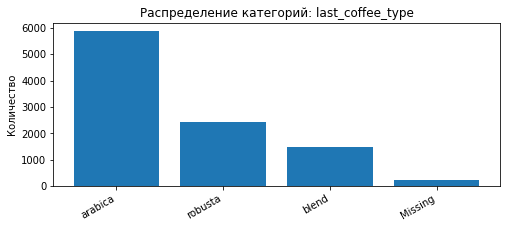

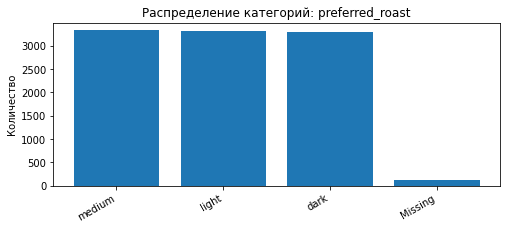

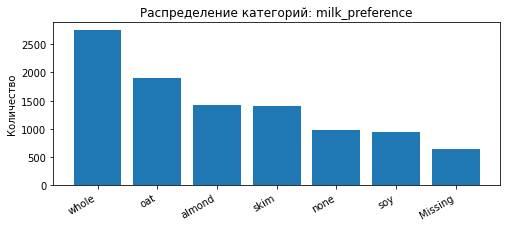

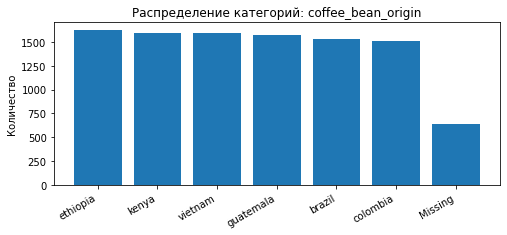

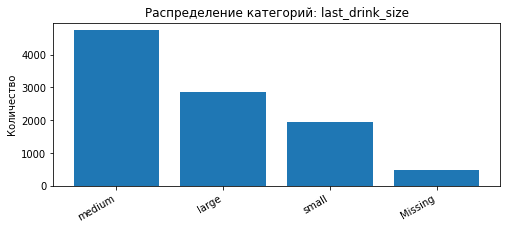

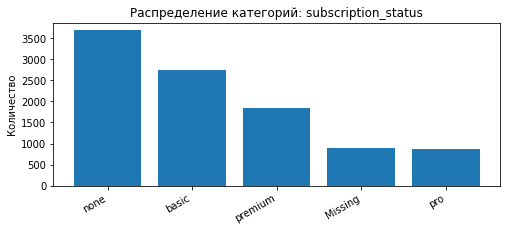

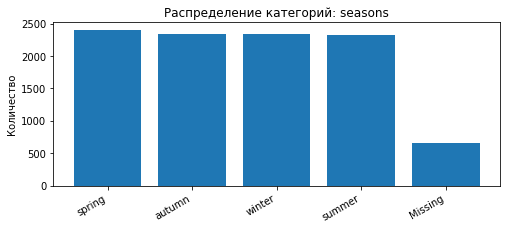

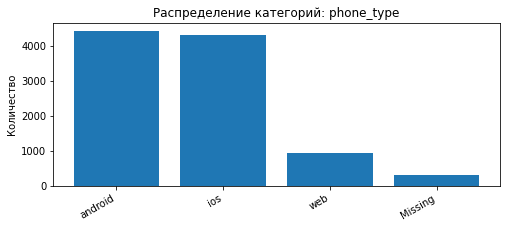

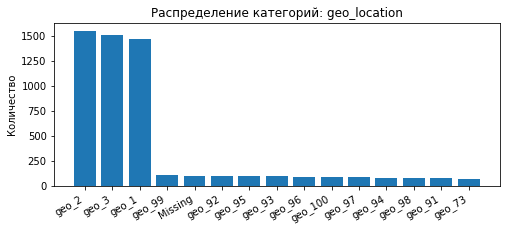

In [31]:
# Частоты категорий(включая NaN) для всех строковых cat_cols

for col in cat_cols:
    vc = df[col].fillna("Missing").astype(str).value_counts()

    # Для geo_location ограничим топ 15
    if col == "geo_location":
        vc = vc.head(15)

    plt.figure(figsize=(8, 3))
    plt.bar(vc.index, vc.values)
    plt.title(f"Распределение категорий: {col}")
    plt.ylabel("Количество")
    plt.xticks(rotation=30, ha="right")
    plt.show()

 Доли категорий в большинстве признаков сбалансированы, исключение — `geo_location`, где наблюдается концентрация в нескольких регионах и “хвост” редких категорий; при необходимости редкие регионы можно объединить в Other.

In [32]:
# Задаем функцию для построения графиков
def plot_churn_by_category(df, col, target='churn', top_n = None):
    tmp = df[[col, target]].copy()
    tmp[col] = tmp[col].fillna('Missing').astype(str)

    if top_n is not None:
        top = tmp[col].value_counts().head(top_n).index
        tmp = tmp[tmp[col].isin(top)]

    stats = tmp.groupby(col)[target].agg(["mean", "count"])

    # 1) churn rate
    stats_mean = stats.sort_values("mean", ascending=False)
    plt.figure(figsize=(10, 3))
    plt.bar(stats_mean.index, stats_mean["mean"].values)
    plt.title(f"Churn rate по категориям: {col}")
    plt.ylabel("Доля churn")
    plt.xticks(rotation=45, ha="right")
    plt.show()

    # 2) количество наблюдений
    stats_count = stats.sort_values("count", ascending=False)
    plt.figure(figsize=(10, 3))
    plt.bar(stats_count.index, stats_count["count"].values)
    plt.title(f"Количество наблюдений по категориям: {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.show()

    display(stats)

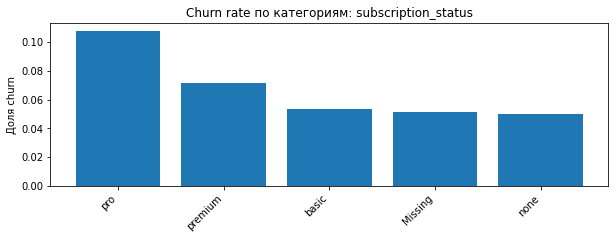

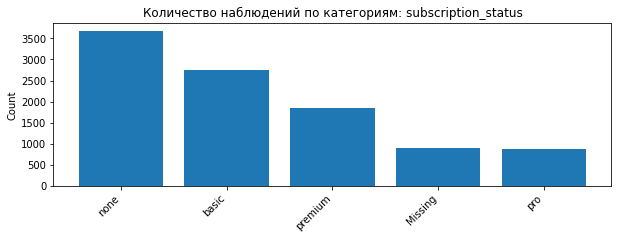

,mean,count
subscription_status,,
Missing,0.051570,892
basic,0.053377,2754
none,0.050014,3679
premium,0.071234,1839
pro,0.107798,872


In [33]:
plot_churn_by_category(df, "subscription_status")

Отток заметно различается по уровню подписки: максимальный churn наблюдается у пользователей с подпиской `pro` (10.8%) и `premium` (7.0%). У групп `basic` и `none` churn ниже (~5–5.4%). Это указывает, что статус подписки может быть значимым предиктором оттока.


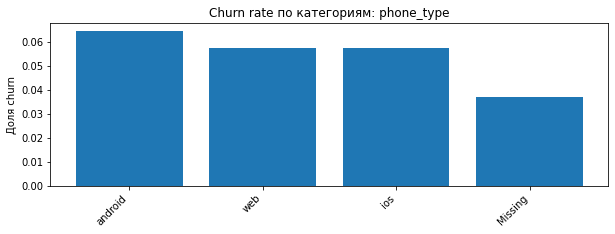

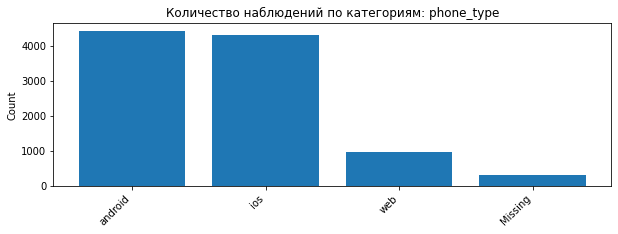

,mean,count
phone_type,,
Missing,0.037037,324
android,0.064654,4439
ios,0.057434,4318
web,0.057592,955


In [34]:
plot_churn_by_category(df, "phone_type")

Тип устройства (`phone_type`) демонстрирует различия в уровне оттока: максимальный `churn` наблюдается у пользователей `android` (6.5%), у `ios` и `web` значения близки (5.7–5.8%). Категория `Missing` имеет более низкий `churn` (3.5%), однако интерпретация ограничена, так как это пропуски. Основная масса наблюдений приходится на `android` и `ios`, поэтому выводы для этих групп наиболее устойчивы.

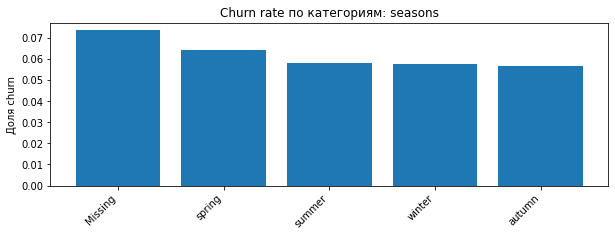

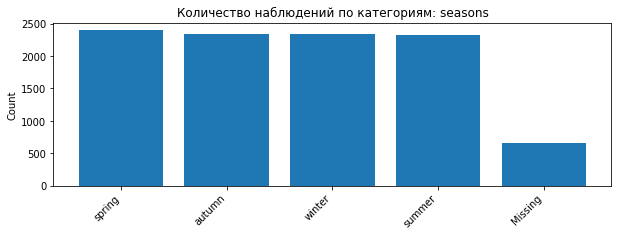

,mean,count
seasons,,
Missing,0.073394,654
autumn,0.056580,2333
spring,0.064247,2397
summer,0.057784,2319
winter,0.057437,2333


In [35]:
plot_churn_by_category(df, "seasons")

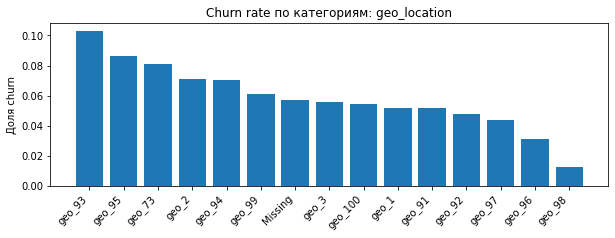

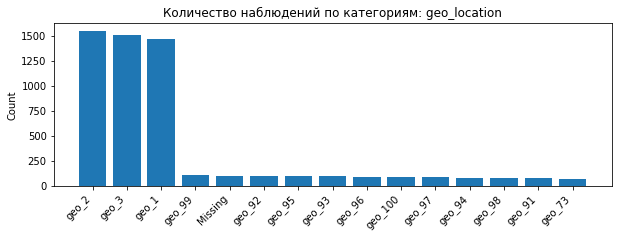

,mean,count
geo_location,,
Missing,0.057143,105
geo_1,0.052168,1476
geo_100,0.054348,92
geo_2,0.070785,1554
geo_3,0.055666,1509
geo_73,0.081081,74
geo_91,0.051948,77
geo_92,0.048077,104
geo_93,0.103093,97


In [36]:
plot_churn_by_category(df, "geo_location", top_n=15)

Для признака `geo_location` наблюдаются заметные различия `churn rate` между регионами. Среди крупных регионов (`geo_1`/`geo_2`/`geo_3`) максимальный `churn` у geo_2 (~7.2%), тогда как geo_1 и geo_3 ближе к 5–5.5%. Для малочисленных регионов `churn` может существенно отличаться (например, geo_93 и geo_95), однако выводы по ним менее устойчивы из-за небольшого числа наблюдений. Поэтому при моделировании возможно объединение редких регионов в категорию Other или использование top-N регионов.

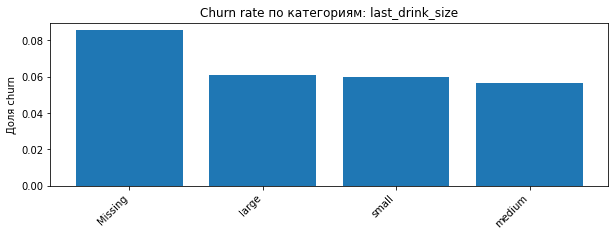

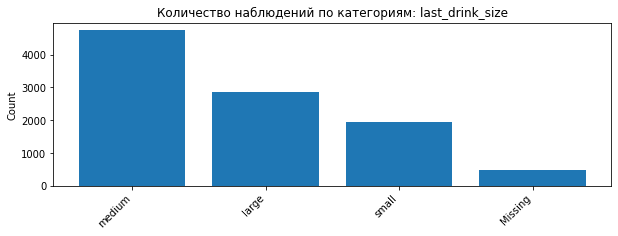

,mean,count
last_drink_size,,
Missing,0.085540,491
large,0.061061,2866
medium,0.056751,4740
small,0.059825,1939


In [37]:
plot_churn_by_category(df, 'last_drink_size')

Для признака `last_drink_size` различия `churn rate` между категориями невелики: значения для medium и small близки (5.8%), для large churn немного выше (6.1%). Категория Missing демонстрирует более высокий churn (8.3%), что может указывать на неслучайный характер пропусков (например, неполные данные о заказе).

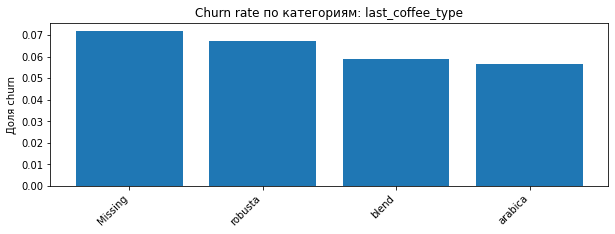

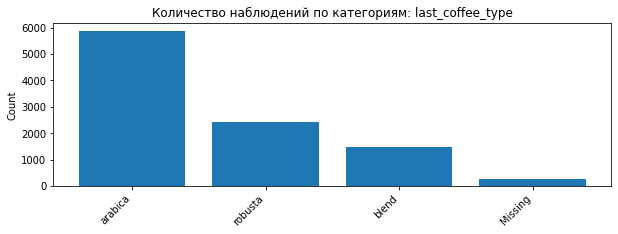

,mean,count
last_coffee_type,,
Missing,0.072000,250
arabica,0.056745,5886
blend,0.058943,1476
robusta,0.067244,2424


In [38]:
plot_churn_by_category(df, 'last_coffee_type')

У клиентов, чей последний сорт кофе robusta, churn выше (~6.6%), чем у arabica (~5.7%). Различия умеренные, но стабильные, так как основные категории представлены большим числом наблюдений.

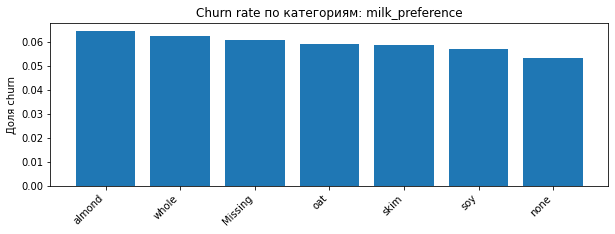

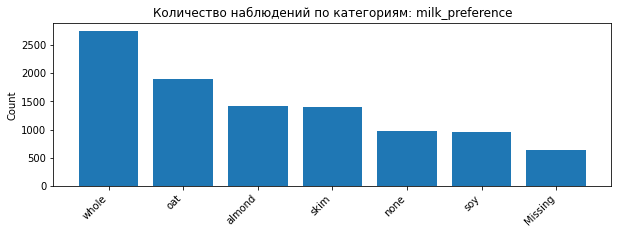

,mean,count
milk_preference,,
Missing,0.060842,641
almond,0.064516,1426
none,0.053388,974
oat,0.058916,1901
skim,0.058697,1397
soy,0.056902,949
whole,0.062227,2748


In [39]:
plot_churn_by_category(df, 'milk_preference')

Для milk_preference churn различается незначительно: максимальные значения у almond (~6.5%) и whole (~6.2%), минимальные у none (~5.5%).

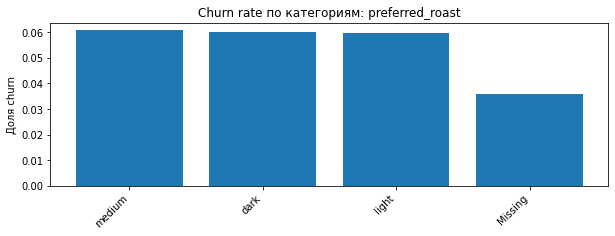

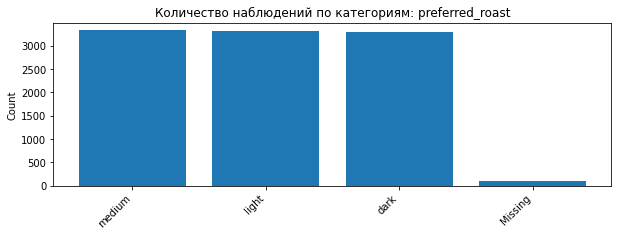

,mean,count
preferred_roast,,
Missing,0.036036,111
dark,0.060219,3288
light,0.059801,3311
medium,0.060734,3326


In [40]:
plot_churn_by_category(df, 'preferred_roast')

Тип обжарки (preferred_roast) показывает очень близкие значения churn для light/medium/dark (~6.0%), что может указывать на слабую предиктивность признака.

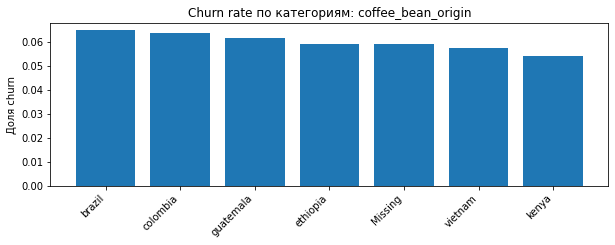

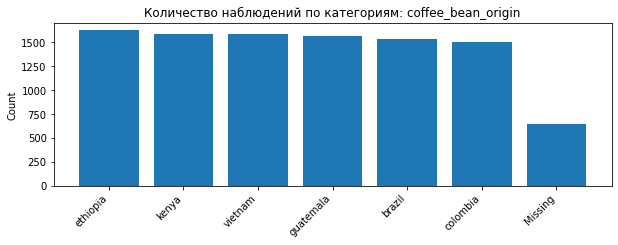

,mean,count
coffee_bean_origin,,
Missing,0.059190,642
brazil,0.064664,1531
colombia,0.063745,1506
ethiopia,0.059223,1621
guatemala,0.061342,1565
kenya,0.054224,1586
vietnam,0.057413,1585


In [41]:
plot_churn_by_category(df, 'coffee_bean_origin')

Страна происхождения зерна демонстрирует умеренные различия churn: максимальный churn у brazil (6.5%), минимальный у kenya (5.4%). Категории сбалансированы по количеству наблюдений, поэтому сравнение устойчивое;

seasonal_menu_tried
0.0    0.063073
1.0    0.060544
Name: churn, dtype: float64

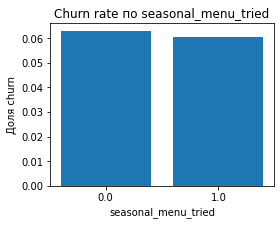

notifications_enabled
0.0    0.062633
1.0    0.058955
Name: churn, dtype: float64

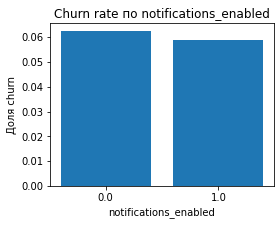

coffee_preference_change
0.0    0.059255
1.0    0.060789
Name: churn, dtype: float64

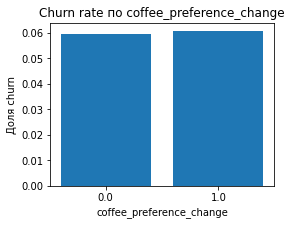

In [42]:
# зависимость от churn для бинарных
bin_cols = ["seasonal_menu_tried", "notifications_enabled", "coffee_preference_change"]

for col in bin_cols:
    rate = df.groupby(col)['churn'].mean()
    display(rate)

    plt.figure(figsize=(4, 3))
    plt.bar(rate.index.astype(str), rate.values)
    plt.title(f"Churn rate по {col}")
    plt.ylabel("Доля churn")
    plt.xlabel(col)
    plt.show()

Для бинарных признаков различия churn между значениями 0/1 невелики. coffee_preference_change практически не связан с оттоком (доли почти равны). notifications_enabled и seasonal_menu_tried показывают слабую тенденцию к снижению churn при значении 1, что может отражать более высокую вовлечённость пользователей, однако эффект небольшой.

При иследвоании признаков можно точно сделать вывод что стоит удалить user_id, так как он не несет никакой смысловой нагрузки для модели, но при этом может привести к переобучению. На основе некоторых категориальных признаков можно создать новые:

- Создать бинарный признак is_subscriber (есть подписка / нет подписки).
- ак как geo_location имеет много значений и “хвост” редких регионов, можно объединять редкие категории в Other (например по порогу частоты или оставлять топ-N регионов, остальные → Other).
- last_coffee_type × preferred_roast
- ilk_preference × last_coffee_type
- last_drink_size × last_coffee_type

Последнии триварианта могут поймать интерсные патерны на вкусы, но с ними стоит быть осторожнее, чтобы не пергрузить модель.

### Изучаем выбросы в данных

При исследовании числовых признаков мы уже видели выбросы, сейчас сконцентрируемся на их детальном изучении, и предположим способы работы с ними

In [43]:
# Задаём функцию для построения графиков:
def plot_outliers_numeric(df, col, bins=50):
    s = df[col].dropna().copy()

    plt.figure(figsize=(10, 3))

    # 1) Boxplot
    plt.subplot(1, 2, 1)
    plt.boxplot(s, vert=True)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)

    # 2) Histogram
    plt.subplot(1, 2, 2)
    plt.hist(s, bins=bins)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

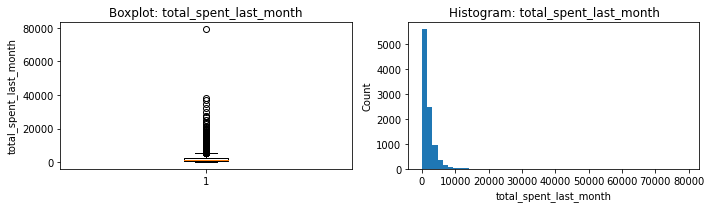

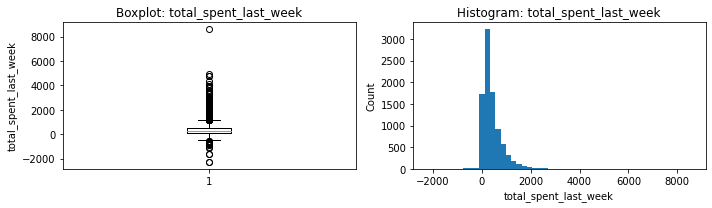

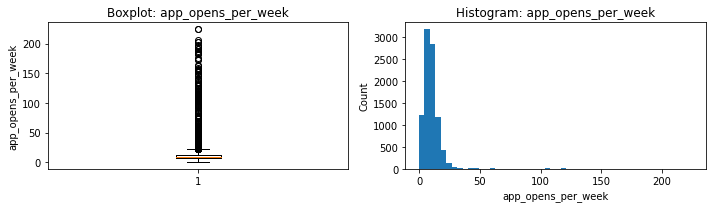

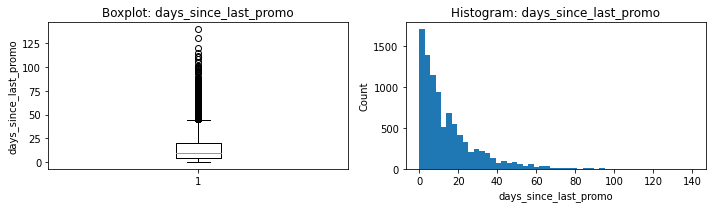

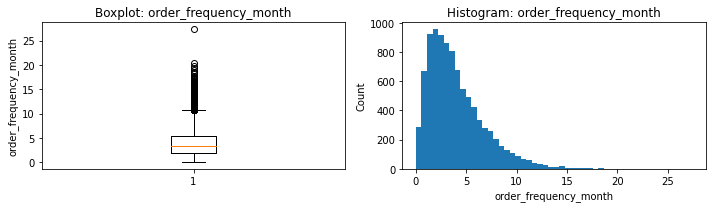

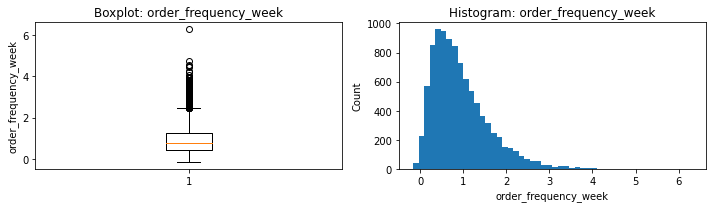

In [44]:
outlier_cols = [
    "total_spent_last_month",
    "total_spent_last_week",
    "app_opens_per_week",
    "days_since_last_promo",
    "order_frequency_month",
    "order_frequency_week",
]
for col in outlier_cols:
    plot_outliers_numeric(df, col)

In [45]:
def hist_with_cap(df, col, q=0.99, bins=50):
    s = df[col].dropna()
    cap = s.quantile(q)

    plt.figure(figsize=(8, 3))
    plt.hist(s[s <= cap], bins=bins)
    plt.title(f"Histogram (<= {int(q*100)}-й перцентиль): {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

    print(f"{col}: cap at q{int(q*100)} = {cap:.2f}, max = {s.max():.2f}")

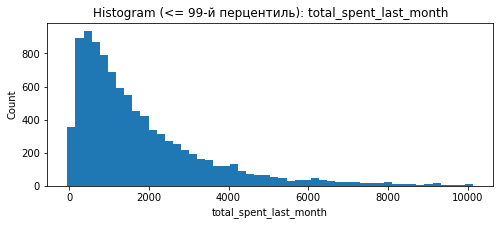

total_spent_last_month: cap at q99 = 10160.73, max = 79298.85


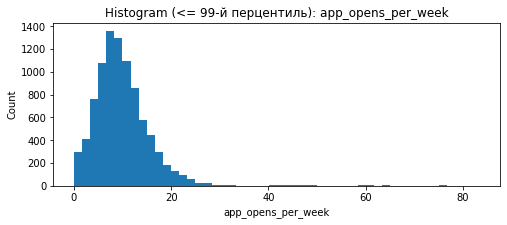

app_opens_per_week: cap at q99 = 83.54, max = 224.59


In [46]:
hist_with_cap(df, "total_spent_last_month", q=0.99)
hist_with_cap(df, "app_opens_per_week", q=0.99)

В числовых признаках выявлены выраженные правые хвосты и выбросы, особенно в total_spent_last_month, total_spent_last_week и app_opens_per_week, а также редкие экстремальные значения в частотах заказов. Такие значения сжимают основную массу наблюдений и могут снижать устойчивость обучения линейной модели при стандартизации. Кроме того, обнаружены невалидные отрицательные значения в отдельных признаках, которые будут приведены к 0 как к нижней допустимой границе. Для снижения влияния экстремальных значений будет рассмотрено ограничение верхних хвостов по квантилям (например q99) перед применением StandardScaler в составе пайплайна.

### Исследуем корреляцию признаков между собой и с target

In [47]:
# подготовка данных к phi_k

target = 'churn'
id_col = 'user_id'

binary_cols = ["seasonal_menu_tried", "notifications_enabled", "coffee_preference_change"]

features = [c for c in df.columns if c  not in [target, id_col]]
tmp = df[features].copy()

# строковые категориальные
cat_cols = tmp.select_dtypes(include=["object", "string"]).columns.tolist()

# числовые (кроме бинарных)
num_cols = tmp.select_dtypes(include=["number"]).columns.tolist()
cont_cols = [c for c in num_cols if c not in binary_cols]

# заполняем пропуски
tmp[cont_cols] = tmp[cont_cols].fillna(tmp[cont_cols].median())
tmp[cat_cols] = tmp[cat_cols].fillna("Missing").astype(str)

# бинарные: заполняем модой (чаще всего 0)
for c in binary_cols:
    tmp[c] = tmp[c].fillna(tmp[c].mode().iloc[0])

# tmp готов для phi_k (без пропусков)
tmp.head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location
0,0.0,12.942519,0.783019,316.833872,260.645090,3089.991009,287.099474,0.337031,blend,light,...,30.468321,1.0,5.176792,3.302238,1.0,summer,6.0,android,0.0,geo_75
1,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,...,9.214974,1.0,4.392991,3.989637,0.0,autumn,16.0,ios,0.0,geo_95
2,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,...,17.895637,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25
3,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,0.263945,robusta,medium,...,11.405533,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2
4,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,...,15.948239,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19


In [48]:
# Считаем корреляцию между признаками
phik_corr = tmp.phik_matrix(interval_cols=cont_cols)

phik_corr

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location
days_since_last_order,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.015549,0.000000,0.006867,...,0.000000,0.000000,0.000000,0.063820,0.000000,0.000000,0.000000,0.000000,0.006352,0.066524
order_frequency_month,0.000000,1.000000,0.985177,0.000000,0.095581,0.383647,0.459379,0.005947,0.000000,0.000000,...,0.188505,0.000000,0.020481,0.000000,0.007486,0.004597,0.000000,0.000000,0.003451,0.110577
order_frequency_week,0.000000,0.985177,1.000000,0.000000,0.092411,0.367346,0.457373,0.023012,0.000000,0.000000,...,0.169657,0.008396,0.000000,0.000000,0.000000,0.009732,0.000000,0.000000,0.007851,0.131714
avg_order_value,0.000000,0.000000,0.000000,1.000000,0.874156,0.158779,0.268231,0.028124,0.000000,0.000000,...,0.000000,0.000000,0.034797,0.000000,0.022448,0.000000,0.057645,0.000000,0.000000,0.025968
median_order_value,0.000000,0.095581,0.092411,0.874156,1.000000,0.440273,0.683637,0.025617,0.010728,0.000000,...,0.000000,0.033038,0.024338,0.000000,0.000000,0.006132,0.000000,0.013556,0.010062,0.000000
total_spent_last_month,0.000000,0.383647,0.367346,0.158779,0.440273,1.000000,0.570917,0.028247,0.000000,0.000000,...,0.435713,0.000000,0.000000,0.000000,0.000000,0.012585,0.000000,0.000000,0.025726,0.054229
total_spent_last_week,0.000000,0.459379,0.457373,0.268231,0.683637,0.570917,1.000000,0.000000,0.000000,0.000000,...,0.080785,0.000000,0.000000,0.000000,0.000000,0.008130,0.000000,0.000000,0.000000,0.000000
discount_usage_rate,0.015549,0.005947,0.023012,0.028124,0.025617,0.028247,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.011764,0.000000,0.000000,0.000000,0.017136,0.000000,0.000000,0.027863,0.065809
last_coffee_type,0.000000,0.000000,0.000000,0.000000,0.010728,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.019032,0.018439,0.000000,0.036013,0.000000,0.025055,0.000000,0.002454,0.000000
preferred_roast,0.006867,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.005659,0.004978,0.019304,0.000000,0.000000,0.000000,0.000000,0.047356,0.000000,0.000000


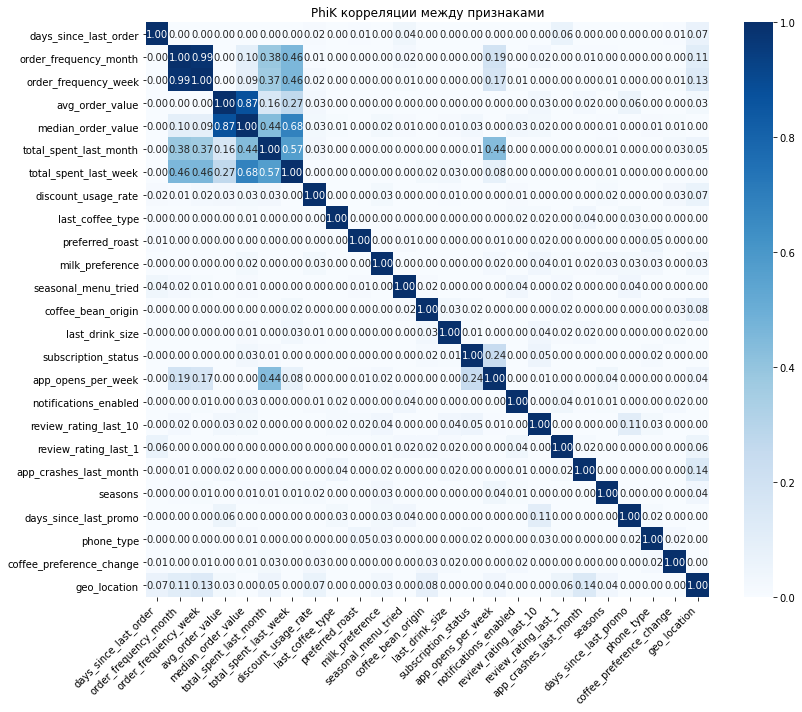

In [49]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    phik_corr,
    vmin=0, vmax=1,
    cmap="Blues",
    annot=True,        # <-- показывать значения
    fmt=".2f"          # <-- 2 знака после запятой
)
plt.title("PhiK корреляции между признаками")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

1.	order_frequency_month ↔ order_frequency_week ~ 0.99
Это почти одно и то же -> для линейной модели (LogReg) обычно оставляют один.
2. avg_order_value и median_order_value ~ 0.87
Тоже сильная связь -> логично оставить один.

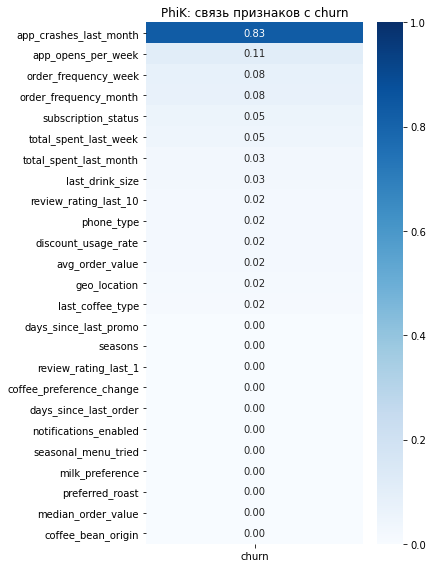

app_crashes_last_month    0.831268
app_opens_per_week        0.112481
order_frequency_week      0.081985
order_frequency_month     0.077534
subscription_status       0.054869
total_spent_last_week     0.047298
total_spent_last_month    0.030449
last_drink_size           0.028719
review_rating_last_10     0.023339
phone_type                0.023061
discount_usage_rate       0.020958
avg_order_value           0.020817
geo_location              0.019200
last_coffee_type          0.015306
days_since_last_promo     0.000000
Name: churn, dtype: float64

In [50]:
# Корреляция с target

tmp_t = tmp.copy()
tmp_t["churn"] = df["churn"]

phik_with_target = tmp_t.phik_matrix(interval_cols=cont_cols)

phik_target = (
    phik_with_target["churn"]
    .drop("churn")
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 8))
sns.heatmap(phik_target.to_frame(), vmin=0, vmax=1, cmap="Blues", annot=True, fmt=".2f")
plt.title("PhiK: связь признаков с churn")
plt.tight_layout()
plt.show()

phik_target.head(15)

In [51]:
# удаляем идентификатор:
df = df.drop(columns=["user_id"])

In [52]:
drop_corr_cols = ["order_frequency_week", "avg_order_value"]
df_model = df.drop(columns=drop_corr_cols).copy()

По корреляциям `PhiK` с целевой переменной churn наибольшая связь наблюдается у признака `app_crashes_last_month` (phi_k 0.83), что может указывать на влияние технических проблем приложения на отток. Умеренная связь также обнаружена у показателей активности и покупательского поведения: `app_opens_per_week` (0.12), `order_frequency_week/month` (0.08), `total_spent_last_week` (0.06), `subscription_status` (0.05). Большинство остальных признаков демонстрируют слабую связь (phi_k близко к 0), однако окончательное решение об их исключении будет приниматься по результатам обучения baseline-модели и оценки качества на валидации

По матрице `PhiK` выявлены сильно коррелирующие пары (`order_frequency_week`–`order_frequency_month`, `avg_order_value`–`median_order_value`). Для снижения мультиколлинеарности планируется оставить `order_frequency_month` и `median_order_value`, а вторые признаки рассмотреть как кандидаты на исключение; финальное решение подтвердим по качеству модели на валидации.

### Выводы по EDA

**Данные и объект наблюдения.**
Датасет представляет собой готовую витрину: 1 строка = 1 клиент, признаки агрегированы за последние 4 недели. Всего 10 450 клиентов и 27 столбцов (16 числовых, 10 строковых, 1 целевой).

**Дубликаты.**
Полных дублей и дублей по user_id нет. При проверке «квази-дубликатов» (совпадение всех признаков при разных user_id) обнаружены повторяющиеся профили, но конфликтов по target нет (одинаковые X не имеют разных значений churn). Это означает, что такие повторения не создают логических противоречий и могут быть следствием одинакового поведения разных клиентов.

**Целевая переменная и дисбаланс.**
churn распределён несбалансированно: ~94% класса 0 и ~6% класса 1 (уходящие клиенты). Это подтверждает необходимость использовать метрику PR AUC и применять стратификацию при разбиении/кросс-валидации.

**Пропуски.**
Пропуски есть во многих признаках. В среднем по всем ячейкам доля пропусков около 5.43%, при этом примерно 78.19% строк содержат хотя бы один пропуск. Пропуски присутствуют и в числовых, и в категориальных признаках (в ряде признаков около 6–9% пропусков).
Для предотвращения утечки данных заполнение пропусков и любые преобразования будут выполняться внутри пайплайна (на этапе предобработки), отдельно для числовых и категориальных признаков.

**Распределения и выбросы (числовые признаки).**
Большинство числовых признаков имеет скошенные распределения и заметные выбросы (особенно в денежных показателях и активности в приложении). Зафиксированы редкие экстремальные значения, например:
	•	total_spent_last_month имеет очень длинный хвост (значения значительно выше 99-го перцентиля),
	•	app_opens_per_week также содержит экстремальные значения.
Также обнаружены отрицательные значения в отдельных финансовых и поведенческих признаках (total_spent_last_week, частоты/чеки и др.). Возможная причина — возвраты/корректировки. Способ обработки (например, клиппинг/замена отрицательных на 0 или отдельная стратегия) будет выбран на этапе предобработки и проверен по качеству модели.

**Категориальные признаки.**
Категориальные признаки имеют небольшое число категорий (обычно 3–6), кроме geo_location (около 100 регионов). Для категориальных признаков планируется кодирование через OneHotEncoder (включая обработку значения Missing). Для geo_location возможна стратегия ограничения/группировки редких категорий (например, top-N + “Other”) — решение будет приниматьcя после оценки качества модели.

**Корреляции между признаками (PhiK).**
По матрице PhiK выявлены пары признаков с высокой взаимосвязью:
	•	order_frequency_month ↔ order_frequency_week (~0.99),
	•	avg_order_value ↔ median_order_value (~0.87).
Для снижения мультиколлинеарности в линейной модели рассматривается сохранение order_frequency_month и median_order_value, а order_frequency_week и avg_order_value — как кандидаты на исключение (финально подтвердим на валидации).

**Связь признаков с целевой переменной (PhiK).**
Наиболее сильная связь с churn наблюдается у app_crashes_last_month (phi_k ≈ 0.83), что может указывать на влияние технических проблем приложения на отток. Умеренная связь обнаружена у показателей активности и покупательского поведения (app_opens_per_week, частоты заказов, траты, subscription_status, geo_location), тогда как многие признаки показывают слабую связь в одиночку. Окончательные выводы о важности признаков будут сделаны после обучения baseline и анализа коэффициентов/качества.


## Этап 3. Предобработка данных

1. Разделим данные в пропорции 80 к 20. 20% данных отложим для теста. Остальные используем для обучения и кросс-валидации модели.

2. Предобработаем данные. Используем информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создадим пайплайн, который обработает пропуски и выбросы.

   - Создадим пайплайн, который обработает категориальные признаки.

   - Создадим пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [53]:
# Отделяем 20% на test
RANDOM_STATE = 42

X = df_model.drop(columns=[target])
y = df_model[target]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2,  shuffle=True, stratify=y, random_state=RANDOM_STATE)

# Проверяем
X_train_val.shape, X_test.shape, y_train_val.mean(), y_test.mean()

((8028, 23), (2008, 23), 0.060039860488290984, 0.05976095617529881)

In [54]:
# Повторно определяю числовые и категориальные признаки, но теперь тольео на Train
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder

def neg_to_zero_func(X):
    return np.maximum(X, 0)

geo_col = "geo_location"

cat_cols = X_train_val.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = X_train_val.select_dtypes(include=['number']).columns.tolist()

cat_cols_oh = [c for c in cat_cols if c != geo_col]

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, q_low=0.01, q_high=0.99):
        self.q_low = q_low
        self.q_high = q_high

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)

        # считаем нижнюю и верхнюю границу для каждого столбца отдельно
        self.low_ = np.nanquantile(X, self.q_low, axis=0)
        self.high_ = np.nanquantile(X, self.q_high, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)

        # обрезаем значения по границам, которые запомнили в fit()
        return np.clip(X, self.low_, self.high_)

    def get_feature_names_out(self, input_features=None):
        return input_features

neg_to_zero = FunctionTransformer(
    neg_to_zero_func,
    feature_names_out="one-to-one"
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('neg_to_zero', neg_to_zero),
    ('clip', QuantileClipper(0.01, 0.99)),
    ('scaler', StandardScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

geo_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('te', TargetEncoder(random_state=RANDOM_STATE))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols_oh),
    ('geo', geo_pipe, [geo_col])
])

X_train_prep = preprocess.fit_transform(X_train_val, y_train_val)
X_test_prep = preprocess.transform(X_test)

ImportError: cannot import name 'TargetEncoder' from 'sklearn.preprocessing' (/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/__init__.py)

In [ ]:
# Проверка
print("num:", len(num_cols), num_cols)
print("cat (ohe):", len(cat_cols_oh), cat_cols_oh)
print("geo:", geo_col)

In [ ]:
# Сборка пайплайн + модель
model_pipe = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])

## Этап 4. Обучение модели

1. Обучаем базовую версию модели.
   - Используем для этого простые статистические модели.

   - Используем кросс-валидацию для обучения модели.

2. Посчитаем метрики, поставленные в задаче. Опираясь на них, сделаем вывод о качестве модели.

In [ ]:
# Baseline: DummyClassifier + CV (PR AUC)
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

RANDOM_STATE = 42

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "accuracy": "accuracy"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dummy_pipe = Pipeline([
    ('preprocessor', preprocess),
    ('dummy', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])

dummy_scores = cross_validate(
    dummy_pipe,
    X_train_val, y_train_val,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for m in scoring.keys():
    vals = dummy_scores[f"test_{m}"]
    print(f"{m}: {vals.mean():.4f} +/- {vals.std():.4f}")

Baseline-модель DummyClassifier со стратегией most_frequent всегда предсказывает класс 0 (не отток). Из-за дисбаланса классов accuracy получилась высокой (0.94), но модель полностью игнорирует класс churn=1: precision/recall/f1 равны 0. PR AUC (0.06) примерно равен доле положительного класса и отражает “уровень пола”, с которым будем сравнивать более сложные модели. ROC AUC = 0.5, то есть модель не отличает классы лучше случайного угадывания.

## Этап 5. Создание новых признаков

1. Добавим новые признаки, которые могут улучшить качество модели. Опираемся на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновляем пайплайн для работы с новыми признаками, проводим повторную кросс-валидацию, сравниваем результаты моделей с новыми признаками и без них.

3. Интерпретируем коэффициенты модели, а затем на их основании выявляем значимые признаки и удаляем лишние для модели.

In [ ]:
# Генирация новых признаков
class FeatureAdder(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        def to_num(s):
            return pd.to_numeric(s, errors='coerce')

        def safe_div(a, b):
            b = b.replace(0, np.nan)
            return (a / b).replace([np.inf, -np.inf], np.nan)

        # 1) Sqrt для хвостатых признаков
        for col in ["total_spent_last_month", "app_opens_per_week"]:
            if col in X.columns:
                x = to_num(X[col])
                x_pos = np.maximum(x, 0)
                X[f"{col}_sqrt"] = np.sqrt(x_pos)

        # 2) Квадрат для "давно не было события" (может усиливать риск)
        for col in ["days_since_last_order", "days_since_last_promo"]:
            if col in X.columns:
                x = to_num(X[col])
                x_pos = np.maximum(x, 0)
                X[f"{col}_sq"] = x_pos ** 2

         # 3) Смысловые соотношения/разницы
        if {"total_spent_last_month", "order_frequency_month"}.issubset(X.columns):
            X["spent_per_order_month"] = safe_div(to_num(X["total_spent_last_month"]), to_num(X["order_frequency_month"]))

        if {"review_rating_last_10", "review_rating_last_1"}.issubset(X.columns):
            X["rating_gap"] = to_num(X["review_rating_last_10"]) - to_num(X["review_rating_last_1"])

        if {"days_since_last_promo", "days_since_last_order"}.issubset(X.columns):
            X["promo_minus_order"] = to_num(X["days_since_last_promo"]) - to_num(X["days_since_last_order"])

        if {"app_opens_per_week", "app_crashes_last_month"}.issubset(X.columns):
            X["opens_per_crash"] = safe_div(to_num(X["app_opens_per_week"]), to_num(X["app_crashes_last_month"]) + 1)


        return X

# Сборка новых признаков
X_train_fe = FeatureAdder().fit_transform(X_train_val)

geo_col = "geo_location"

cat_cols_fe = X_train_fe.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols_fe = X_train_fe.select_dtypes(include=["number"]).columns.tolist()

cat_cols_oh_fe = [c for c in cat_cols_fe if c != geo_col]

preprocess_fe = ColumnTransformer([
    ('num', num_pipe, num_cols_fe),
    ('cat', cat_pipe, cat_cols_oh_fe),
    ('geo', geo_pipe, [geo_col])
])

In [ ]:
# Сравниваем до после

# 1) без новых фич
lr_base = Pipeline([
    ('preprocessor', preprocess),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

# 2) с новыми фичами
lr_feat = Pipeline([
    ('feat', FeatureAdder()),
    ('preprocessor', preprocess_fe),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

# dummy повтор

dummy_pipe = Pipeline([
    ('preprocessor', preprocess),
    ('model', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
])

def show_cv(scores, name):
    print(f"\n{name}")
    for m in scoring.keys():
        vals = scores[f"test_{m}"]
        print(f"{m}: {vals.mean():.4f} +/- {vals.std():.4f}")

scores_dummy = cross_validate(dummy_pipe, X_train_val, y_train_val, cv=cv, scoring=scoring, n_jobs=-1)
scores_base  = cross_validate(lr_base,   X_train_val, y_train_val, cv=cv, scoring=scoring, n_jobs=-1)
scores_feat  = cross_validate(lr_feat,   X_train_val, y_train_val, cv=cv, scoring=scoring, n_jobs=-1)

show_cv(scores_dummy, "Dummy baseline (most_frequent)")
show_cv(scores_base,  "LogReg WITHOUT new features")
show_cv(scores_feat,  "LogReg WITH new features")

- Dummy baseline не предсказывает churn=1, поэтому precision/recall/f1 равны нулю и возникают предупреждения о неопределённой precision.
- Логистическая регрессия значительно превосходит baseline по PR AUC и ROC AUC.
- Добавление новых признаков улучшило качество модели: PR AUC вырос с 0.664 до 0.686, recall увеличился с 0.452 до 0.517, F1 вырос с 0.564 до 0.614.
- Следовательно, новые признаки содержат полезную информацию и улучшают способность модели находить клиентов с риском оттока.

In [ ]:
# Изучаем коэффициенты
# 1) обучаем pipeline (с новыми фичами)
lr_feat.fit(X_train_val, y_train_val)

# 2) достаем имена признаков после препроцессинга
feature_names = lr_feat.named_steps['preprocessor'].get_feature_names_out()

# 3) достаем коэффициенты
coefs = lr_feat.named_steps['model'].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df["odds_ratio"] = np.exp(coef_df["coef"])

coef_df.sort_values("abs_coef", ascending=False).head(30)

In [ ]:
# Удаляем слабые признаки по коэффициентам
threshold = 0.01

weak = coef_df[coef_df["abs_coef"] < threshold].copy()

weak.shape, weak.head()

In [ ]:
weak_cols = coef_df.loc[coef_df["abs_coef"] < threshold, "feature"].tolist()

weak_raw = set()

# списки исходных категориальных признаков (до OHE)
cat_base = cat_cols_oh_fe  # или cat_cols_oh, как у тебя в preprocess
num_base = num_cols_fe     # или num_cols
geo_col = "geo_location"

for f in weak_cols:
    if f.startswith("num__"):
        weak_raw.add(f.replace("num__", ""))

    elif f.startswith("geo__"):
        weak_raw.add(geo_col)

    elif f.startswith("cat__"):
        # ищем, какой исходный признак был закодирован
        after = f.replace("cat__", "")
        for c in cat_base:
            if after.startswith(c + "_") or after == c:
                weak_raw.add(c)
                break

weak_raw = sorted(weak_raw)
print("Слабые исходные признаки (по коэффициентам):")
print(weak_raw)
print("Сколько:", len(weak_raw))

In [ ]:
X_train_val_drop = X_train_val.drop(columns=weak_raw, errors="ignore")
X_test_drop = X_test.drop(columns=weak_raw, errors="ignore")

# ВАЖНО: после удаления нужно пересобрать preprocess под новые списки колонок!
cat_cols_new = X_train_val_drop.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols_new = X_train_val_drop.select_dtypes(include=["number"]).columns.tolist()
cat_cols_oh_new = [c for c in cat_cols_new if c != geo_col]

preprocess_new = ColumnTransformer([
    ('num', num_pipe, num_cols_new),
    ('cat', cat_pipe, cat_cols_oh_new),
    ('geo', geo_pipe, [geo_col])
])

lr_new = Pipeline([
    ("feat", FeatureAdder()),
    ("preprocess", preprocess_new),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

scores_new = cross_validate(lr_new, X_train_val_drop, y_train_val, cv=cv, scoring=scoring, n_jobs=-1)
show_cv(scores_new, f"LogReg after drop abs<{threshold}")

“Пробовал отбор по коэффициентам (abs<0.03). Качество по PR AUC / F1 / Recall ухудшилось, поэтому от отбора отказался.”

## Этап 6. Эксперименты с гиперпараметрами

1. Проведём систематический перебор гиперпараметров для `LogisticRegression`, выполним кросс-валидацию для каждой конфигурации.

2. Составим таблицу с результатами.

3. Выберем лучшую модель, ориентируясь на заданную метрику качества.

In [ ]:
scoring ={
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
    'logloss': 'neg_log_loss',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

def make_pipe(C, penalty, solver, class_weight):
    return Pipeline([
        ("feat", FeatureAdder()),
        ("preprocess", preprocess_fe),
        ("model", LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            class_weight=class_weight,
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ])

C_list = [0.01, 0.1, 1, 10]
penalties = ["l1"]
solvers = ["liblinear", "saga"]
class_weights = [None, "balanced"]

results = []

for solver in solvers:
    for penalty in penalties:
        for C in C_list:
            for cw in class_weights:
                pipe = make_pipe(C=C, penalty=penalty, solver=solver, class_weight=cw)

                scores = cross_validate(
                    pipe,
                    X_train_val, y_train_val,
                    cv=cv,
                    scoring=scoring,
                    n_jobs=-1
                )

                row = {
                    "solver": solver,
                    "penalty": penalty,
                    "C": C,
                    "class_weight": str(cw),
                }

                for m in scoring.keys():
                    row[f"{m}_mean"] = scores[f"test_{m}"].mean()
                    row[f"{m}_std"] = scores[f"test_{m}"].std()
                results.append(row)

results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values("pr_auc_mean", ascending=False).reset_index(drop=True)
results_df_sorted.head(20)

In [ ]:
results_df.head(3)

Итог гиперпараметров:
- перебрали C {0.01, 0.1}, solver {liblinear}, class_weight {None, balanced}, penalty = l1.
- лучшая конфигурация по целевой метрике PR AUC:
liblinear + l1 + C=0.1 + class_weight=None
PR AUC = 0.6913 +- 0.0373
- class_weight="balanced" сильно повышает recall (до 0.865), но сильно снижает precision (0.249), из-за чего падает PR AUC и ухудшается logloss.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [ ]:
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    precision_score, recall_score, log_loss, accuracy_score
)

best_model = LogisticRegression(
    solver='liblinear',
    penalty='l1',
    C=0.1,
    class_weight=None,
    max_iter=3000,
    random_state=RANDOM_STATE
)

final_pipe = Pipeline([
    ('feat', FeatureAdder()),
    ('preprocess', preprocess_fe),
    ('model', best_model)
])

final_pipe.fit(X_train_val, y_train_val)

proba_test = final_pipe.predict_proba(X_test)[:, 1]
pred_test = final_pipe.predict(X_test)

# считаем метрики
metrics = {
    "PR AUC": average_precision_score(y_test, proba_test),
    "ROC AUC": roc_auc_score(y_test, proba_test),
    "LogLoss": log_loss(y_test, proba_test),
    "F1": f1_score(y_test, pred_test),
    "Precision": precision_score(y_test, pred_test, zero_division=0),
    "Recall": recall_score(y_test, pred_test),
    "Accuracy": accuracy_score(y_test, pred_test)
}

metrics

1.	Проблемы приложения
]app_crashes_last_month] и производная `opens_per_crash` — сильные сигналы.
Бизнес-смысл: если приложение часто падает, клиент с высокой вероятностью разочаровывается и уходит.
2.	Активность в приложении
`app_opens_per_week` и `app_opens_per_week_sqrt`.
Бизнес-смысл: низкая/падающая активность — ранний индикатор того, что клиент “остывает”.
3.	Подписка / статус клиента
`subscription_status_*` — заметно влияет.
Бизнес-смысл: формат подписки (или её отсутствие) связан с удержанием.
4.	География
`geo_location` влияет на churn.
Бизнес-смысл: в разных регионах разные условия (доставка, конкуренты, промо, сезонность).
5.	Поведение по заказам и промо
Фичи типа `spent_per_order_month`, `promo_minus_order`, `days_since_last_promo` отражают вовлечённость и реакцию на стимулы.

## Этап 8. Отчёт о проделанной работе


1) **Цель и данные**

Цель проекта - построить модель бинарной классификации, которая предсказывает отток клиента в следующем месяце (`churn`).
Данные представлены витриной за последние 4 недели: в таблице есть числовые и категориальные признаки, а также идентификатор `user_id`.
Основная метрика качества по ТЗ - `PR AUC` (важно из-за дисбаланса классов).

---

2) **Результаты EDA**
    - В данных присутствуют пропуски и признаки разных типов (числовые, бинарные, категориальные).
    - Для ряда числовых признаков наблюдаются выбросы и “длинные хвосты” (например, траты и активность в приложении).
    - Были проверены квази-дубликаты (одинаковые строки по признакам при разных `user_id`) — такие наблюдения удалены, чтобы не “дублировать” одинаковых клиентов в обучении.
    - Для анализа взаимосвязей использовалась `PhiK`-корреляция, потому что она подходит для смешанных типов данных (числовые/категориальные/бинарные).
    - Найдены сильно коррелирующие пары признаков, что подтверждает наличие пересекающейся информации в некоторых признаках.
    - Также отдельно оценивалась связь признаков с целевым `churn`.
---

3) **Предобработка**

Данные разделены в пропорции 80/20 на `train_val` и `test` с `stratify=y` и фиксированным `random_state`.

Предобработка реализована через `Pipeline` и `ColumnTransformer`:

 - Числовые признаки:
    - пропуски -> `median`,
    - отрицательные значения -> заменяем на 0 (как некорректные/неинтерпретируемые значения),
    - экстремальные выбросы -> клиппинг по квантилям (1%–99%),
    - масштабирование -> `StandardScaler`.
 - Категориальные признаки:
    - пропуски -> `most_frequent`,
    - `OneHotEncoder(handle_unknown='ignore')`.
 - `geo_location`:
    - применяется `TargetEncoder` (так как много уникальных значений, и `OHE` был бы слишком “раздутым”).
---

4) **Baseline**

В качестве базовой модели использован `DummyClassifier(strategy="most_frequent")` с кросс-валидацией.

Результат `baseline` ожидаемо слабый:
   - `PR AUC` ~ 0.06,
   - `ROC AUC` = 0.5,
   - `F1/Precision/Recall` близки к 0, т.к. модель фактически всегда выбирает самый частый класс.

Вывод: `baseline` подтверждает, что без обучаемой модели качество неудовлетворительное, и требуется полноценная модель.

---

5) **Улучшение модели и новые признаки**

Основная модель - `LogisticRegression` в составе пайплайна.

На основе `EDA` и логики задачи были добавлены новые признаки:
сглаживание хвостатых распределений через `sqrt` для некоторых признаков (например, траты/активность),
усиление влияния “давно не было события” через квадрат (*_sq),
- смысловые комбинации:
    - `spent_per_order_month`,
    - `rating_gap`,
    - `promo_minus_order`,
    - `opens_per_crash`.

После добавления новых признаков качество улучшилось:

   - по `CV` `PR AUC` вырос (по сравнению с вариантом без новых фич),
   - улучшились `F1` и `Recall` при сохранении высокой `Precision`.

---

6) **Интерпретация коэффициентов и вывод по отбору признаков**

Коэффициенты логистической регрессии были проанализированы (в том числе через `abs(coef)` и `odds_ratio`), чтобы понять, какие признаки сильнее влияют на прогноз.

**Важно**:
пробовали удалять признаки с малыми коэффициентами, но это привело к ухудшению качества модели (падение метрик).
Поэтому в финальной версии было принято решение НЕ удалять признаки только на основании коэффициентов, а оставить набор признаков без агрессивного отбора, так как даже “слабые” признаки могут помогать в комбинации и улучшать итоговый `PR AUC`.

---

7) **Гиперпараметры**

Проведён систематический перебор гиперпараметров `LogisticRegression`:
   - `C`,
   - `solver (liblinear, saga)`,
   - `class_weight (None, balanced)`,
   - `penalty='l1'`.

Для каждой конфигурации рассчитаны метрики `CV`:
   - `PR AUC` ,
   - `ROC AUC`,
   - `LogLoss`,
   - `F1, Precision, Recall`.

Лучшая конфигурация выбрана по максимальному `PR AUC`.

---

8) **Финальная модель и оценка на тесте**

Финальный пайплайн обучен на `X_train_val`, после чего выполнена оценка на отложенном `X_test`.

Итоговые метрики на тесте:
   - `PR AUC` = 0.7408
   - `ROC AUC` = 0.9388
   - `LogLoss` = 0.1086
   - `F1` = 0.6289
   - `Precision` = 0.8243
   - `Recall` = 0.5083
   - `Accuracy` = 0.9641

Вывод: модель хорошо ранжирует клиентов по вероятности оттока (высокий `PR AUC`), при этом сохраняет хорошее качество классификации и низкую ошибку вероятностного прогноза (`LogLoss`).

---

9) **Сохранение модели**

Финальный `Pipeline` сохранён с помощью `joblib`.
Проведена проверка корректности: модель загружена из файла и повторно посчитаны метрики на тесте — значения совпали с исходными, значит артефакт сохранён корректно и может использоваться в продакшене.

---

### Общий итог
Baseline показал очень низкое качество, поэтому использовали полноценную модель LogisticRegression.
Качество существенно улучшили:
корректная предобработка (без утечек) внутри пайплайна,
обработка выбросов и масштабирование,
target encoding для geo_location,
генерация новых осмысленных признаков.
Отбор признаков по коэффициентам не применяли в финале, потому что он ухудшал качество.
Финальная модель на тесте показала PR AUC = 0.74, что соответствует хорошему уровню для задачи оттока при дисбалансе классов.


## Этап 9. Сохранение модели для продакшена


In [ ]:
import os
import joblib

ARTIFACT_DIR = 'artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

model_path = os.path.join(ARTIFACT_DIR, 'coffee_churn_final_pipe.joblib')

joblib.dump(final_pipe, model_path)

print('Saved to:', model_path)

In [ ]:
load_pipe = joblib.load(model_path)

proba_test_loaded = load_pipe.predict_proba(X_test)[:, 1]
pred_test_loaded = load_pipe.predict(X_test)

metrics_loaded = {
    "PR AUC": average_precision_score(y_test, proba_test_loaded),
    "ROC AUC": roc_auc_score(y_test, proba_test_loaded),
    "LogLoss": log_loss(y_test, proba_test_loaded),
    "F1": f1_score(y_test, pred_test_loaded),
    "Precision": precision_score(y_test, pred_test_loaded, zero_division=0),
    "Recall": recall_score(y_test, pred_test_loaded),
    "Accuracy": accuracy_score(y_test, pred_test_loaded),
}

metrics_loaded

In [ ]:
import subprocess, sys

req_path = os.path.join(ARTIFACT_DIR, "requirements.txt")
with open(req_path, "w", encoding="utf-8") as f:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=f)

print("Saved to:", req_path)

Финальный пайплайн сохранён в формате `joblib`. Затем пайплайн был загружен обратно и проверен на тестовой выборке. Метрики после загрузки совпали с исходными, значит артефакт корректен и готов к использованию.